# Clausius-Clapeyron refiners on a regular solution

`landau.refine` ships two coexistence-line tracers built on the
predictor-corrector Clausius-Clapeyron idea:

* `ClausiusClapeyronRefiner` — inter-phase boundaries between two
  *distinct* phases.
* `MiscibilityGapRefiner` — intra-phase miscibility gaps where one
  phase splits into two compositions.

This notebook exercises both on toy examples and walks through how to
call them piece by piece for debugging.

For the miscibility-gap demo we use a regular (one-parameter
Redlich-Kister) solution with a repulsive interaction parameter
$L_0 > 0$:

$$f(T, c) = c\,(1-c)\,L_0 - T\,S_\text{mix}(c),$$

$S_\text{mix}(c) = -k_B\,[c\ln c + (1-c)\ln(1-c)]$.  Repulsive
$L_0$ drives phase separation below $T_c = L_0 / (2 k_B)$.

We implement the regular solution analytically (root-find $df/dc=\mu$,
pick the global minimum) so the binodal is a sharp jump — the smoothed
convex-hull interpolation in `landau.phases.RegularSolution` does not
resolve it cleanly at low $T$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.constants import Boltzmann, eV
from scipy.optimize import brentq
import scipy.optimize as so

from landau.phases import Phase
from landau.calculate import calc_phase_diagram, refine_phase_diagram
from landau.refine import ClausiusClapeyronRefiner, MiscibilityGapRefiner

kB = Boltzmann / eV  # eV/K

## Analytical regular solution

Defines a `Phase` subclass that evaluates `semigrand_potential` and
`concentration` directly via global minimisation of $f - \mu c$
(root-finding on $df/dc = \mu$, then picking the deepest minimum).
No stencil artefacts, sharp binodal jumps.

In [2]:
def _S_mix(c):
    c = np.asarray(c, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        return kB * (np.where(c > 0, -c * np.log(c), 0.0)
                     + np.where(c < 1, -(1 - c) * np.log(1 - c), 0.0))


def _dS_dc(c):
    with np.errstate(divide='ignore'):
        return kB * np.log((1.0 - c) / c)


@dataclass(frozen=True)
class AnalyticRegularSolution(Phase):
    """Symmetric regular solution: f = c(1-c) L0 - T S_mix(c)."""
    L0: float

    def _f(self, T, c):
        return c * (1 - c) * self.L0 - T * _S_mix(c)

    def _df_dc(self, T, c):
        return self.L0 * (1 - 2 * c) - T * _dS_dc(c)

    def _stable_c(self, T, mu):
        c_grid = np.linspace(1e-10, 1 - 1e-10, 4000)
        g = self._df_dc(T, c_grid) - mu
        sign_changes = np.where(np.diff(np.sign(g)))[0]
        roots = []
        for i in sign_changes:
            try:
                r = so.brentq(lambda c: self._df_dc(T, c) - mu,
                              c_grid[i], c_grid[i + 1], xtol=1e-12)
                roots.append(r)
            except ValueError:
                pass
        if not roots:
            raise ValueError(f'No root at T={T:.2f} K, mu={mu:.5f} eV')
        if len(roots) == 1:
            return roots[0]
        # Pick the global minimum of g(c) = f(c) - mu c.
        gvals = [self._f(T, r) - mu * r for r in roots]
        return roots[int(np.argmin(gvals))]

    def semigrand_potential(self, T, mu):
        if np.isscalar(mu):
            c = self._stable_c(T, mu)
            return float(self._f(T, c) - mu * c)
        return np.array([self.semigrand_potential(T, m) for m in np.asarray(mu)])

    def concentration(self, T, mu):
        if np.isscalar(mu):
            return float(self._stable_c(T, mu))
        return np.array([self._stable_c(T, m) for m in np.asarray(mu)])


L0 = 0.10  # eV — repulsive interaction parameter
T_c = L0 / (2 * kB)
solution = AnalyticRegularSolution(name='solution', L0=L0)
print(f'analytical T_c = {T_c:.1f} K')

analytical T_c = 580.2 K


Visualize $f(T,c)$ at $\mu = 0$ for a few temperatures — a clear double
well below $T_c$, single minimum above.

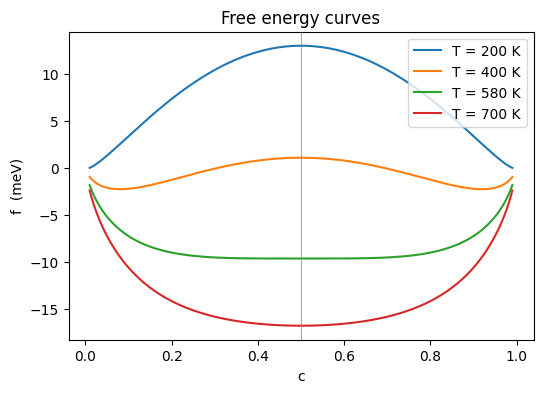

In [3]:
cc = np.linspace(0.01, 0.99, 200)
fig, ax = plt.subplots(figsize=(6, 4))
for T in [200, 400, 580, 700]:
    f = cc * (1 - cc) * L0 + kB * T * (cc * np.log(cc) + (1 - cc) * np.log(1 - cc))
    ax.plot(cc, 1e3 * f, label=f'T = {T} K')
ax.axvline(0.5, color='gray', lw=0.5)
ax.set_xlabel('c'); ax.set_ylabel('f  (meV)')
ax.legend(); ax.set_title('Free energy curves');

## Intra-phase: miscibility-gap tracer

Feed the coarse sampling into `MiscibilityGapRefiner`. The
Delaunay-based refiners do not see this boundary because an
intra-phase miscibility gap appears as a single phase in landau's
data model (both branches carry the same phase name). The sampling
extends past $T_c$; the trace stops on its own when the gap closes.

In [4]:
phases = {solution.name: solution}
Ts  = np.linspace(150, T_c + 250, 30)
mus = np.linspace(-0.05, 0.05, 21)

coarse = calc_phase_diagram([solution], Ts=Ts, mu=mus, refine=False, keep_unstable=True)
df = refine_phase_diagram(coarse, phases, refiners=[MiscibilityGapRefiner()])
cc_pts = df[df['refined'] == 'miscibility-gap'].copy()
print(f'MiscibilityGapRefiner: {len(cc_pts)} refined rows ({cc_pts.groupby(["T", "mu"]).ngroups} unique (T, mu))')
print(f'Input T range: [{Ts.min():.0f}, {Ts.max():.0f}] K  (T_c = {T_c:.0f} K)')
print(f'Traced  T range: [{cc_pts["T"].min():.1f}, {cc_pts["T"].max():.1f}] K  -- the trace stops on its own once the gap closes')

MiscibilityGapRefiner: 62 refined rows (31 unique (T, mu))
Input T range: [150, 830] K  (T_c = 580 K)
Traced  T range: [150.0, 584.7] K  -- the trace stops on its own once the gap closes


## Coexistence line and binodal

* Left: coexistence chemical potential $\mu^*(T)$. By the $c \leftrightarrow 1-c$
  symmetry of the regular solution $\mu^*(T) \equiv 0$ — the refiner should
  reproduce this exactly within the bisection tolerance.
* Right: binodal in $(c, T)$ — refined points overlaid on the analytical
  binodal $L_0(1-2c) = T k_B \ln((1-c)/c)$.

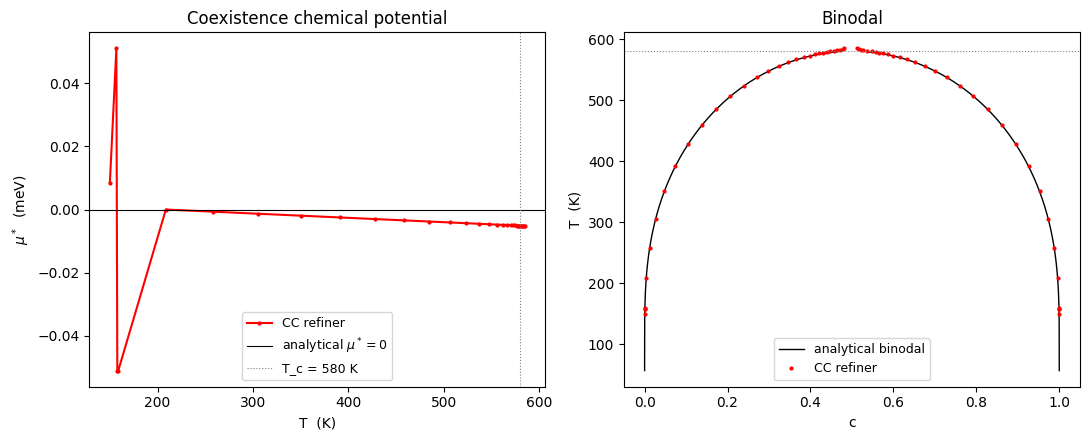

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- left: coexistence chemical potential mu*(T) ---
ax = axes[0]
cc_mu = cc_pts.groupby('T')['mu'].mean().reset_index().sort_values('T')
ax.plot(cc_mu['T'], 1e3 * cc_mu['mu'], 'r.-', ms=4, label='CC refiner')
ax.axhline(0.0, color='k', lw=0.8, label=r'analytical $\mu^*=0$')
ax.axvline(T_c, ls=':', color='gray', lw=0.8, label=f'T_c = {T_c:.0f} K')
ax.set_xlabel('T  (K)')
ax.set_ylabel(r'$\mu^*$  (meV)')
ax.set_title('Coexistence chemical potential')
ax.legend(fontsize=9)

# --- right: binodal ---
ax = axes[1]
T_grid = np.linspace(50, T_c - 1, 400)
c_bin = []
for T in T_grid:
    def dfdc(c, T=T):
        return L0 * (1 - 2 * c) + kB * T * (np.log(c) - np.log(1 - c))
    try:
        c_bin.append(brentq(dfdc, 1e-9, 0.5 - 1e-6))
    except ValueError:
        c_bin.append(np.nan)
c_bin = np.array(c_bin)
ax.plot(c_bin,     T_grid, 'k-', lw=1, label='analytical binodal')
ax.plot(1 - c_bin, T_grid, 'k-', lw=1)
ax.plot(cc_pts['c'], cc_pts['T'], 'r.', ms=4, label='CC refiner')
ax.axhline(T_c, ls=':', color='gray', lw=0.8)
ax.set_xlabel('c'); ax.set_ylabel('T  (K)')
ax.set_title('Binodal')
ax.legend(fontsize=9)

plt.tight_layout()

## Accuracy summary

In [6]:
print(f'CC refiner traced {cc_pts.groupby(["T","mu"]).ngroups} coexistence points')
print(f'  T range covered = {cc_pts["T"].min():.1f} - {cc_pts["T"].max():.1f} K')
print(f'  max |mu*|       = {np.abs(cc_pts["mu"]).max():.2e} eV  (analytical: 0)')
print(f'  median |mu*|    = {np.median(np.abs(cc_pts["mu"])):.2e} eV')

CC refiner traced 31 coexistence points
  T range covered = 150.0 - 584.7 K
  max |mu*|       = 5.10e-05 eV  (analytical: 0)
  median |mu*|    = 4.98e-06 eV


## Step-by-step walkthrough

Driver code path for the refiner so you can poke at each stage
individually. Useful for debugging the propose/solve/run pipeline.

In [7]:
# 1. Coarse stable points -- input to the refiner.
sdf = coarse[coarse['stable']].copy()
print(f'Coarse stable rows: {len(sdf)}')
print(sdf.head())

Coarse stable rows: 630
       T     phase           phi     mu         c  stable     locus  \
0  150.0  solution -1.179545e-07 -0.050  0.000009    True  interior   
1  150.0  solution -1.736684e-07 -0.045  0.000013    True  interior   
2  150.0  solution -2.557015e-07 -0.040  0.000020    True  interior   
3  150.0  solution -3.764916e-07 -0.035  0.000029    True  interior   
4  150.0  solution -5.543591e-07 -0.030  0.000043    True  interior   

              f      f_excess  
0 -5.742532e-07 -4.562986e-07  
1 -7.783286e-07 -6.603741e-07  
2 -1.047093e-06 -9.291385e-07  
3 -1.396141e-06 -1.278186e-06  
4 -1.841373e-06 -1.723418e-06  


In [8]:
# 2. propose() -- candidates from single-phase Delaunay simplices with
# wide c-spread, sorted widest first.
refiner = MiscibilityGapRefiner()
cands = list(refiner.propose(sdf))
print(f'Total candidates: {len(cands)}\n')
print('First 5:')
for i, c in enumerate(cands[:5]):
    print(f'  [{i:3d}] phase={c.phase:8s} T_seed={c.T_seed:6.1f}  '
          f'T_bracket=({c.T_bracket[0]:6.1f}, {c.T_bracket[1]:6.1f})  '
          f'mu_bracket=({c.mu_bracket[0]:+.4f}, {c.mu_bracket[1]:+.4f})')
print('...')

Total candidates: 52

First 5:
  [  0] phase=solution T_seed= 157.8  T_bracket=( 150.0,  173.5)  mu_bracket=(-0.0050, +0.0000)
  [  1] phase=solution T_seed= 165.6  T_bracket=( 150.0,  173.5)  mu_bracket=(-0.0050, +0.0000)
  [  2] phase=solution T_seed= 181.3  T_bracket=( 173.5,  196.9)  mu_bracket=(-0.0050, +0.0000)
  [  3] phase=solution T_seed= 189.1  T_bracket=( 173.5,  196.9)  mu_bracket=(-0.0050, +0.0000)
  [  4] phase=solution T_seed= 189.1  T_bracket=( 173.5,  196.9)  mu_bracket=(+0.0000, +0.0050)
...


In [9]:
# 3. solve() on one candidate -- scan-seed + predictor-corrector trace.
pts = list(refiner.solve(cands[0], phases))
print(f'{len(pts)} refined transitions')
print(f'  T range: [{min(p.T for p in pts):.1f}, {max(p.T for p in pts):.1f}] K')
print(f'  mu range: [{min(p.mu for p in pts):+.3e}, {max(p.mu for p in pts):+.3e}] eV')
print(f'  type: {type(pts[0]).__name__}')

31 refined transitions
  T range: [150.0, 584.7] K
  mu range: [-5.102e-05, +5.102e-05] eV
  type: RefinedMiscibilityGap


In [10]:
# 4. run() -- orchestrator that calls propose() then solve(), and
# applies the per-pair straddle dedup so candidates whose simplex is
# already crossed by an existing trace are skipped.
out = refiner.run(sdf, phases)
print(f'Run produced {len(out)} rows ({out.groupby(["T", "mu"]).ngroups} unique (T, mu))')
print()
print('First few rows:')
print(out.head())

Run produced 62 rows (31 unique (T, mu))

First few rows:
            T            mu       phi         c     phase  boundary_id  \
0  157.818689 -5.102041e-05 -0.000009  0.000641  solution            0   
1  157.818689 -5.102041e-05 -0.000009  0.999354  solution            0   
2  158.818689 -5.102041e-05 -0.000009  0.000672  solution            0   
3  158.818689 -5.102041e-05 -0.000009  0.999323  solution            0   
4  208.683848 -1.127570e-17 -0.000071  0.003999  solution            0   

      locus  stable  border          refined  
0  boundary    True    True  miscibility-gap  
1  boundary    True    True  miscibility-gap  
2  boundary    True    True  miscibility-gap  
3  boundary    True    True  miscibility-gap  
4  boundary    True    True  miscibility-gap  


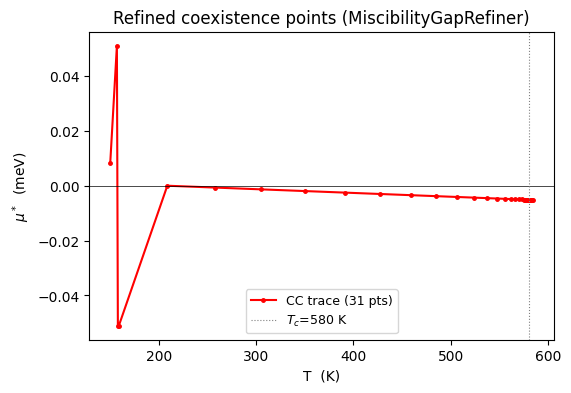

In [11]:
# 5. Refined coexistence points -- single contiguous trace.
fig, ax = plt.subplots(figsize=(6, 4))
pts_sorted = out.drop_duplicates(['T', 'mu']).sort_values('T')
ax.plot(pts_sorted['T'], 1e3 * pts_sorted['mu'], 'r.-', ms=5,
        label=f'CC trace ({len(pts_sorted)} pts)')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(T_c, ls=':', color='gray', lw=0.8, label=f'$T_c$={T_c:.0f} K')
ax.set_xlabel('T  (K)')
ax.set_ylabel(r'$\mu^*$  (meV)')
ax.set_title('Refined coexistence points (MiscibilityGapRefiner)')
ax.legend(fontsize=9)

## Inter-phase boundary: solid / liquid (ideal-solution binary)

Now switch to `ClausiusClapeyronRefiner`, which handles two-phase
coexistence between *distinct* phases. The example is the classic
solidus/liquidus from `notebooks/IdealSolution.ipynb`. The refiner
seeds via projection across the two phases' vertex centroids in
each Delaunay simplex, guaranteeing a brentq bracket on
`phi1 - phi2`, then walks T from that seed point.

In [12]:
from landau.phases import LinePhase, IdealSolution

solid_a  = LinePhase('A',    fixed_concentration=0, line_energy=-2.0, line_entropy=1.0 * kB)
solid_b  = LinePhase('B',    fixed_concentration=1, line_energy=-3.0, line_entropy=1.5 * kB)
liquid_a = LinePhase('A(l)', fixed_concentration=0, line_energy=-1.9, line_entropy=2.5 * kB)
liquid_b = LinePhase('B(l)', fixed_concentration=1, line_energy=-2.9, line_entropy=2.2 * kB)
solid  = IdealSolution('solid',  solid_a,  solid_b)
liquid = IdealSolution('liquid', liquid_a, liquid_b)

Ts_ip  = np.linspace(200, 1800, 25)
mus_ip = np.linspace(-0.3, 0.3, 21)
phases_ip = {'solid': solid, 'liquid': liquid}
coarse_ip = calc_phase_diagram(
    [solid, liquid], Ts=Ts_ip, mu=mus_ip, refine=False, keep_unstable=False)
out_ip = refine_phase_diagram(coarse_ip, phases_ip,
                              refiners=[ClausiusClapeyronRefiner()])
cc_ip = out_ip[out_ip['refined'] == 'clausius-clapeyron']
print(f'Refined {cc_ip.groupby(["T", "mu"]).ngroups} coexistence points '
      f'across T = [{cc_ip["T"].min():.0f}, {cc_ip["T"].max():.0f}] K')

Refined 87 coexistence points across T = [775, 1658] K


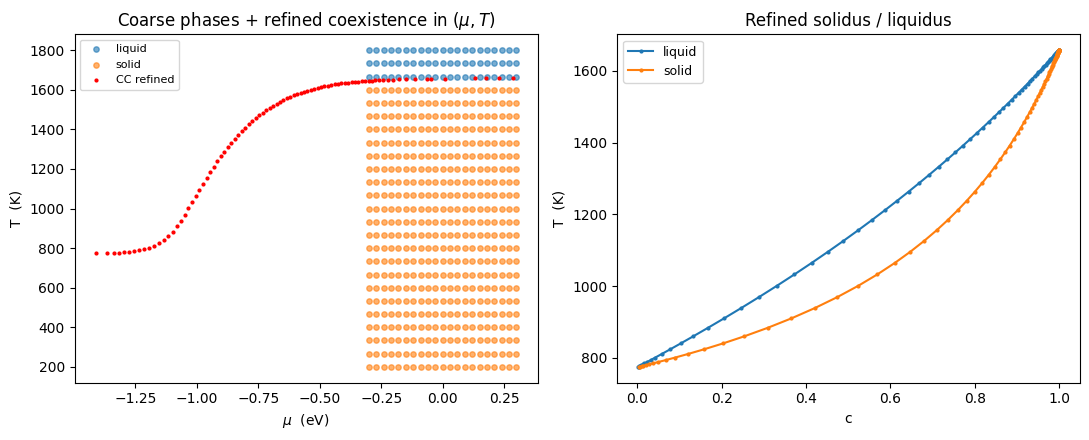

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Coarse stable points coloured by phase + refined coexistence overlay.
ax = axes[0]
for ph, group in coarse_ip[coarse_ip['stable']].groupby('phase'):
    ax.scatter(group['mu'], group['T'], s=15, label=ph, alpha=0.6)
refined_T = cc_ip.drop_duplicates(['T', 'mu']).sort_values('T')
ax.plot(refined_T['mu'], refined_T['T'], 'r.', ms=4, label='CC refined')
ax.set_xlabel(r'$\mu$  (eV)')
ax.set_ylabel('T  (K)')
ax.set_title(r'Coarse phases + refined coexistence in $(\mu, T)$')
ax.legend(fontsize=8)

# c vs T view: liquidus and solidus branches.
ax = axes[1]
for ph, group in cc_ip.groupby('phase'):
    g = group.sort_values('T')
    ax.plot(g['c'], g['T'], '.-', ms=4, label=ph)
ax.set_xlabel('c'); ax.set_ylabel('T  (K)')
ax.set_title('Refined solidus / liquidus')
ax.legend(fontsize=9)

plt.tight_layout()

## Asymmetric miscibility gap (sub-regular solution)

A sub-regular solution $f_\text{mix} = c(1-c)(L_0 + L_1(2c-1))$ with
$L_1 \neq 0$ breaks the $c \leftrightarrow 1-c$ symmetry, so
$\mu^*(T) \neq 0$ and the binodal is skewed
($c_\text{left} + c_\text{right} \neq 1$).  We build it as a
`FastInterpolatingPhase` with `RedlichKister(2)` fitted to control
points sampling the analytical $f_\text{mix}$, then re-run the same
refiner.

In [14]:
from landau.phases import FastInterpolatingPhase
from landau.interpolate import RedlichKister

L0_asym, L1_asym = 0.10, 0.04

def _f_mix_asym(c):
    return c * (1 - c) * (L0_asym + L1_asym * (2 * c - 1))

control_cs = (0.0, 0.25, 0.5, 0.75, 1.0)
asym_line_phases = [
    LinePhase(name=f'p{i}', fixed_concentration=c,
              line_energy=_f_mix_asym(c), line_entropy=0.0)
    for i, c in enumerate(control_cs)
]
asym_phase = FastInterpolatingPhase(
    name='sub', phases=asym_line_phases,
    add_entropy=True, interpolator=RedlichKister(2),
)

Ts_asym  = np.linspace(150, 700, 18)
mus_asym = np.linspace(-0.05, 0.05, 21)
coarse_asym = calc_phase_diagram(
    [asym_phase], Ts=Ts_asym, mu=mus_asym,
    refine=False, keep_unstable=True)
df_asym = refine_phase_diagram(
    coarse_asym, {'sub': asym_phase},
    refiners=[MiscibilityGapRefiner()])
cc_asym = df_asym[df_asym['refined'] == 'miscibility-gap']

print(f'asymmetric trace: {cc_asym.groupby(["T","mu"]).ngroups} pts, '
      f'T=[{cc_asym["T"].min():.0f}, {cc_asym["T"].max():.0f}] K')
print(f'  median |mu*| = {np.median(np.abs(cc_asym["mu"])) * 1e3:.2f} meV  (would be 0 for symmetric)')

pairs = cc_asym.groupby(['T', 'mu'])['c'].agg(
    lambda s: (float(min(s)), float(max(s))))
sums = np.array([cl + cr for cl, cr in pairs])
print(f'  median (c_left + c_right) = {np.median(sums):.3f}  (would be 1 for symmetric)')

asymmetric trace: 33 pts, T=[150, 700] K
  median |mu*| = 14.55 meV  (would be 0 for symmetric)
  median (c_left + c_right) = 1.275  (would be 1 for symmetric)


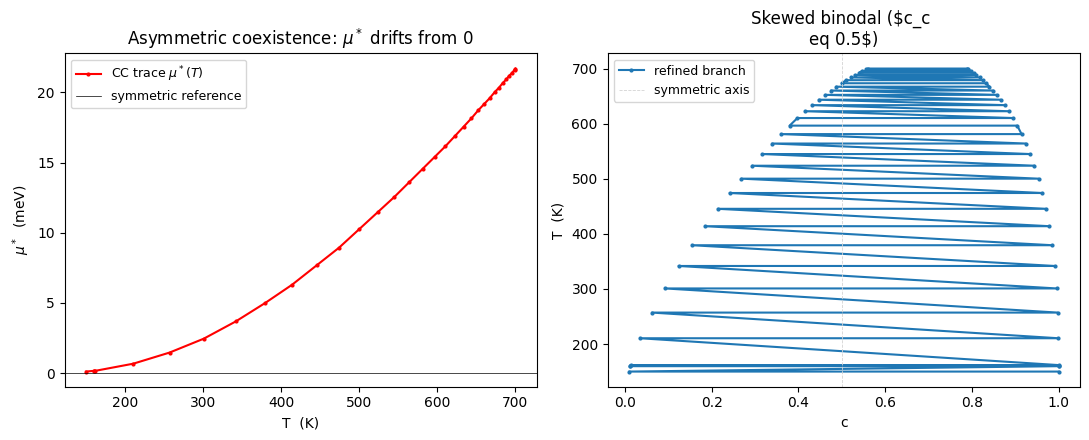

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# mu*(T)
ax = axes[0]
trace = cc_asym.drop_duplicates(['T', 'mu']).sort_values('T')
ax.plot(trace['T'], 1e3 * trace['mu'], 'r.-', ms=4, label=r'CC trace $\mu^*(T)$')
ax.axhline(0, color='k', lw=0.5, label='symmetric reference')
ax.set_xlabel('T  (K)'); ax.set_ylabel(r'$\mu^*$  (meV)')
ax.set_title('Asymmetric coexistence: $\mu^*$ drifts from 0')
ax.legend(fontsize=9)

# Binodal in (c, T)
ax = axes[1]
for ph, group in cc_asym.groupby('phase'):
    g = group.sort_values('T')
    ax.plot(g['c'], g['T'], '.-', ms=4, label='refined branch')
ax.axvline(0.5, ls='--', color='lightgray', lw=0.6, label='symmetric axis')
ax.set_xlabel('c'); ax.set_ylabel('T  (K)')
ax.set_title('Skewed binodal ($c_c \neq 0.5$)')
ax.legend(fontsize=9)

plt.tight_layout()